# Customer Sentiment in Product Reviews

In [63]:
# ===============================
# Core Python Libraries
# ===============================
import os
import pickle
import joblib
import numpy as np
import pandas as pd
from collections import Counter
from scipy.special import expit  # sigmoid

# ===============================
# Data Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ===============================
# NLP: NLTK & Gensim
# ===============================
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.util import ngrams

# ===============================
# Scikit-learn: Preprocessing, Models, Metrics
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDClassifier, PassiveAggressiveClassifier

# ===============================
# NGBoost
# ===============================
from ngboost import NGBClassifier
from ngboost.distns import Bernoulli

# ===============================
# TensorFlow / Keras
# ===============================
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Input, Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# ===============================
# Transformers (Hugging Face)
# ===============================
from transformers import (
    AutoTokenizer, AutoModel,
    RobertaTokenizer, RobertaModel,
    BertTokenizer, BertForSequenceClassification,
    XLNetTokenizer, XLNetForSequenceClassification
)
import torch
from torch.optim import AdamW

# ===============================
# Custom Modules
# ===============================
from metrics_calculator import MetricsCalculator
from graphs import GraphPlotter

MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)

In [33]:
import nltk

# Tokenizer
nltk.download('punkt', quiet=True)

# Stopwords
nltk.download('stopwords', quiet=True)

# WordNet for lemmatizer
nltk.download('wordnet', quiet=True)

#  POS tagging for better lemmatization
nltk.download('averaged_perceptron_tagger', quiet=True)

nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sripa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\sripa\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [34]:
labels = ["Cannot Say", "Negative", "Positive", "Neutral"]

metrics_calculator_lb = MetricsCalculator(labels)


In [35]:
def upload_dataset(file_path):
    """Load the dataset from a CSV file"""
    df = pd.read_csv(file_path,)
    return df

In [36]:
path=r"Dataset/Train.csv"

In [37]:
df= upload_dataset(path)
df

,Text_ID,Product_Description,Product_Type,Sentiment
0,3057,The Web DesignerÛªs Guide to iOS (and Android...,9,2
1,6254,RT @mention Line for iPad 2 is longer today th...,9,2
2,8212,Crazy that Apple is opening a temporary store ...,9,2
3,4422,The lesson from Google One Pass: In this digit...,9,2
4,5526,RT @mention At the panel: &quot;Your mom has a...,9,2
...,...,...,...,...
6359,2945,Thanks @mention for hosting this event #sxsw #...,9,2
6360,4528,"SXSW iPhone app is awesome, but iPad app crash...",7,1
6361,6526,RT @mention RT @mention Download 20+ free trac...,9,2
6362,2110,OH at Texas Social Media Awards: 'You don't ne...,9,2


In [38]:
def preprocess_data(df, save_path=None, target_cols=None):

    global label_encoders
    label_encoders = {}  # dictionary to hold encoders for each target column

    if save_path and os.path.exists(save_path):
        print(f"Loading existing preprocessed file: {save_path}")
        df = pd.read_csv(save_path)
    else:
        print("Preprocessing data" + (f" and saving to: {save_path}" if save_path else " (no saving)"))
        lemmatizer = WordNetLemmatizer()
        stop_words = set(stopwords.words('english'))

        def clean_text(text):
            text = str(text).lower()
            tokens = word_tokenize(text)
            tokens = [lemmatizer.lemmatize(t) for t in tokens if t.isalnum() and t not in stop_words]
            return ' '.join(tokens)

        # Separate target columns
        target_df = None
        if target_cols:
            existing_targets = [col for col in target_cols if col in df.columns]
            target_df = df[existing_targets].copy()
            df = df.drop(columns=existing_targets)

        # Process text columns
        text_columns = df.select_dtypes(include='object').columns
        for col in text_columns:
            df[f'processed_{col}'] = df[col].apply(clean_text)

        # Drop original text columns
        df.drop(columns=text_columns, inplace=True)

        # Reattach target columns
        if target_df is not None:
            for col in target_df.columns:
                df[col] = target_df[col]

        # Save only if path is specified
        if save_path:
            df.to_csv(save_path, index=False)

    # Select processed and numerical columns
    processed_text_cols = [col for col in df.columns if col.startswith('processed_')]
    non_text_cols = [col for col in df.columns if col not in processed_text_cols + (target_cols if target_cols else [])]

    # Join processed text columns into one string
    X_text = df[processed_text_cols].astype(str).agg(' '.join, axis=1)

    # Combine with numerical columns if any
    X_numeric = df[non_text_cols].values if non_text_cols else None
    if X_numeric is not None and len(X_numeric) > 0:
        X = [f"{text} {' '.join(map(str, numeric))}" for text, numeric in zip(X_text, X_numeric)]
    else:
        X = X_text.tolist()

    # Encode multiple target columns
    Y_dict = {}
    if target_cols:
        for col in target_cols:
            if col in df.columns:
                le = LabelEncoder()
                Y_dict[col] = le.fit_transform(df[col])
                label_encoders[col] = le

    return X, Y_dict

In [39]:
X, Y_dict = preprocess_data(df, save_path="cleaned_data.csv", target_cols=["Sentiment"])

Loading existing preprocessed file: cleaned_data.csv


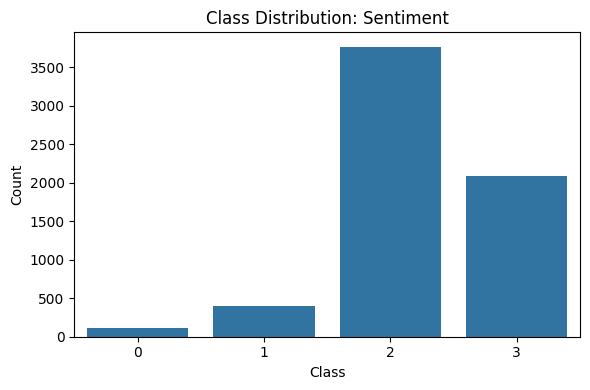

In [40]:
def plot_target_distributions(Y_dict):
    """
    Create count plots for each target column in Y_dict.
    
    Parameters:
        Y_dict (dict): Dictionary where keys are target column names and values are encoded label arrays.
    """
    # Convert to DataFrame for easy plotting
    y_df = pd.DataFrame(Y_dict)

    # Plot each column
    for col in y_df.columns:
        plt.figure(figsize=(6, 4))
        sns.countplot(x=y_df[col])
        plt.title(f'Class Distribution: {col}')
        plt.xlabel('Class')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()
plot_target_distributions(Y_dict)


In [41]:
def eda_nlp_analysis(X_text, num_words=100, top_n_words=20):
    """
    Perform NLP EDA:
        1. WordCloud
        2. Top N words
        3. Document length histogram
        4. POS tag frequency
        5. Bigram frequency

    Parameters:
        X_text (list of str): Input preprocessed text data.
        num_words (int): Number of words to show in word cloud.
        top_n_words (int): Number of top frequent words to plot.
    """
    print("Generating NLP EDA Visualizations...")

    # Flatten all tokens from all texts
    all_tokens = [word for doc in X_text for word in word_tokenize(doc)]

    # --- 1. WordCloud ---
    word_freq = Counter(all_tokens)
    wc = WordCloud(width=800, height=400, max_words=num_words, background_color='white').generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Top {num_words} Words - WordCloud")
    plt.show()

    # --- 2. Top-N Frequent Words ---
    common_words = word_freq.most_common(top_n_words)
    words, counts = zip(*common_words)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(words), palette="viridis")
    plt.title(f"Top {top_n_words} Most Frequent Words")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.show()

    # --- 3. Document Length Histogram ---
    doc_lengths = [len(word_tokenize(doc)) for doc in X_text]
    plt.figure(figsize=(10, 5))
    sns.histplot(doc_lengths, bins=20, kde=True, color='teal')
    plt.title("Distribution of Document Lengths (in words)")
    plt.xlabel("Number of Words per Document")
    plt.ylabel("Frequency")
    plt.show()

    # --- 4. POS Tag Frequency ---
    all_pos = [tag for _, tag in pos_tag(all_tokens)]
    pos_counts = Counter(all_pos).most_common()
    pos_tags, pos_freqs = zip(*pos_counts)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(pos_tags), y=list(pos_freqs), palette="coolwarm")
    plt.title("Part of Speech (POS) Tag Frequency")
    plt.xlabel("POS Tag")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()

    # --- 5. Bigram Frequency Plot ---
    bigrams = list(ngrams(all_tokens, 2))
    bigram_freq = Counter(bigrams).most_common(top_n_words)
    bigram_labels = [' '.join(b) for b, _ in bigram_freq]
    bigram_counts = [count for _, count in bigram_freq]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=bigram_counts, y=bigram_labels, palette="magma")
    plt.title(f"Top {top_n_words} Bigrams")
    plt.xlabel("Count")
    plt.ylabel("Bigram")
    plt.show()


Generating NLP EDA Visualizations...


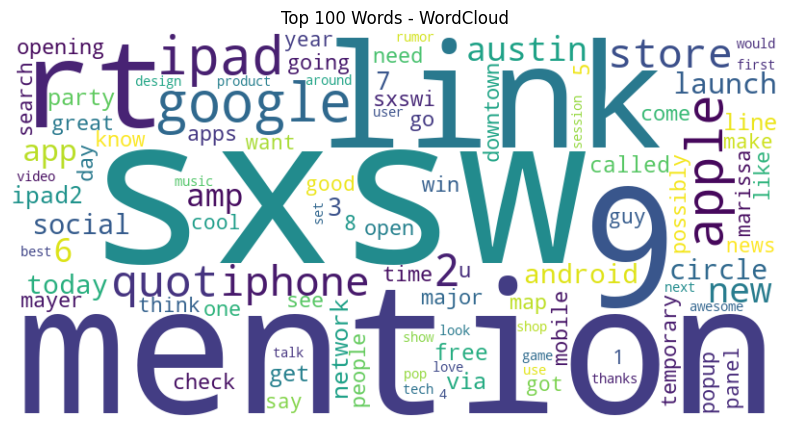

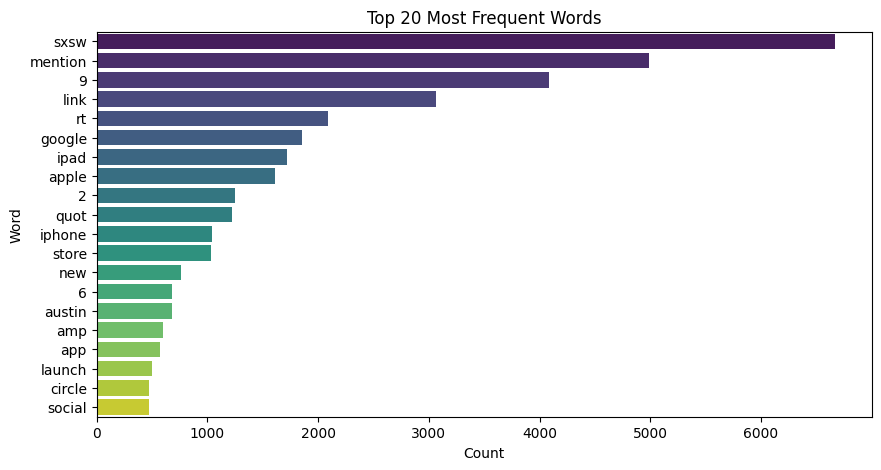

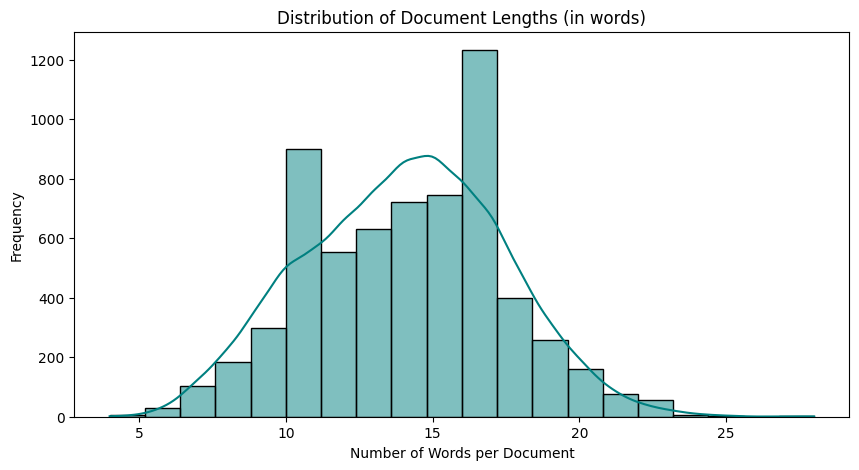

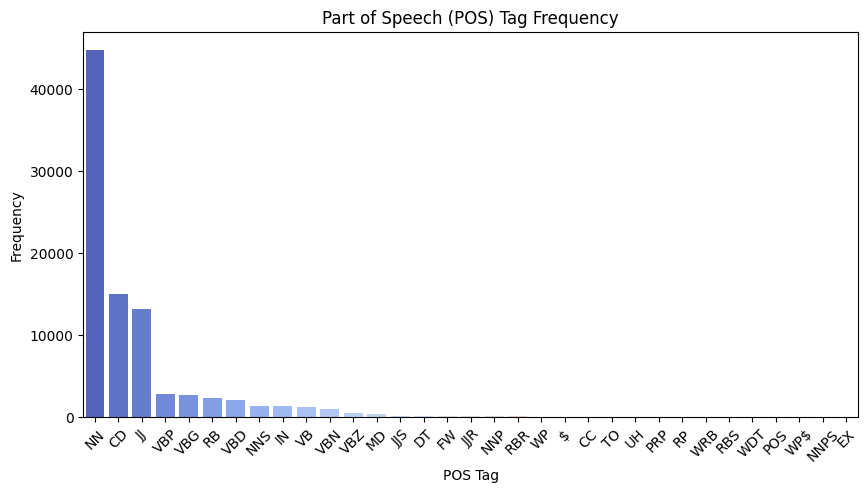

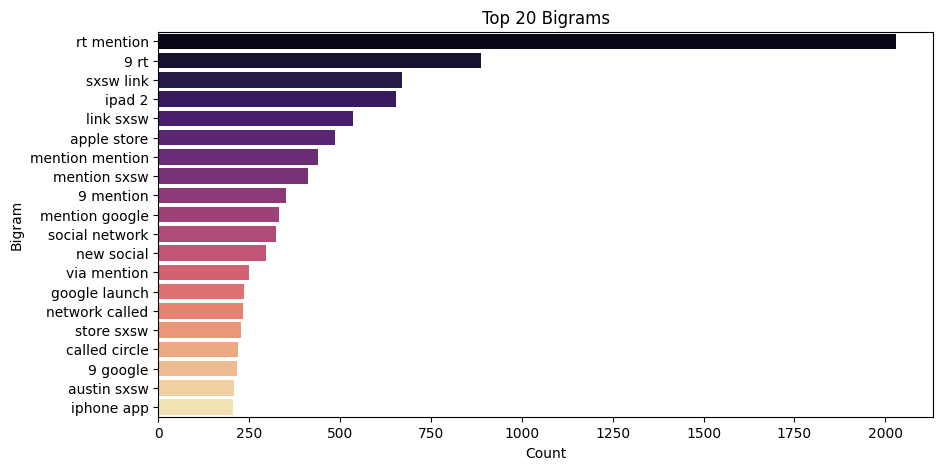

In [42]:
eda_nlp_analysis(X_text=X, num_words=100, top_n_words=20)

In [43]:
from tqdm import tqdm
def bert_feature_extraction(texts, model_name='bert-base-uncased', batch_size=32, pooling='mean'):
    """Extract BERT features from texts with tqdm progress bar."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()

    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting BERT embeddings"):
        batch_texts = texts[i:i+batch_size]
        encoded_input = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt')

        with torch.no_grad():
            model_output = model(**encoded_input)

        token_embeddings = model_output.last_hidden_state  # shape: [batch_size, seq_len, hidden_dim]
        attention_mask = encoded_input['attention_mask']
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

        if pooling == 'mean':
            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
            sum_mask = input_mask_expanded.sum(dim=1)
            embeddings = sum_embeddings / sum_mask
        elif pooling == 'cls':
            embeddings = token_embeddings[:, 0, :]  # CLS token
        else:
            raise ValueError("Pooling must be 'mean' or 'cls'")

        all_embeddings.append(embeddings.cpu().numpy())

    X = np.vstack(all_embeddings)
    return X, model

def feature_extraction(X_text, method='BERT_word_embeddings', model_dir='model', is_train=True):
    x_file = os.path.join(model_dir, f'X_{method}.pkl')

    print(f"[INFO] Feature extraction method: {method}, Train mode: {is_train}")
    model_name = 'bert-base-uncased'

    if os.path.exists(x_file):
            print(f"[INFO] Loading cached BERT features from {x_file}")
            X = joblib.load(x_file)
    else:
            print("[INFO] Computing BERT features...")
            X, model = bert_feature_extraction(X_text, model_name=model_name, pooling='mean')
            joblib.dump(X, x_file)
 
    return X

In [44]:
features = feature_extraction(X, method='SBERT with Word Embeddings',is_train=True)

[INFO] Feature extraction method: SBERT with Word Embeddings, Train mode: True
[INFO] Loading cached BERT features from model\X_SBERT with Word Embeddings.pkl


In [45]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

features_smoted = {}
labels_smoted = {}

for i, (key, y) in enumerate(Y_dict.items(), start=1):
    X_resampled, y_resampled = smote.fit_resample(features, y)
    features_smoted[f'features{i}'] = X_resampled
    labels_smoted[f'Y{i}'] = y_resampled
    print(f"Balanced '{key}' class: features{i}.shape = {X_resampled.shape}, Y{i}.shape = {y_resampled.shape}")

features_dict = {
    'Sentiment': features_smoted['features1']
}

labels_dict = {
    'Sentiment': labels_smoted['Y1']
}

Balanced 'Sentiment' class: features1.shape = (15060, 768), Y1.shape = (15060,)


In [46]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

def train_multioutput_ml_ensemble(Algorithm_prefix, features_dict, Y_dict):
    ml_models = {}

    for target_name, y_encoded in Y_dict.items():
        X = features_dict[target_name]

        # Define model configurations
        model_configs = {
            "RFC": RandomForestClassifier(),
            "LGBM": LGBMClassifier(),
            "XGB": XGBClassifier()
        }

        for model_name, model_instance in model_configs.items():
            model_path = f"model/{Algorithm_prefix}_{target_name}_{model_name}_model.pkl"
            algo_name = f"{Algorithm_prefix} {model_name} [{target_name}]"

            X_train, X_test, y_train, y_test = train_test_split(
                X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
            )

            if os.path.exists(model_path):
                print(f"Loading existing {model_name} model for {target_name}...")
                mdl = joblib.load(model_path)
            else:
                print(f"Training {model_name} for target: {target_name}...")
                mdl = model_instance
                mdl.fit(X_train, y_train)
                joblib.dump(mdl, model_path)

            y_pred = mdl.predict(X_test)
            try:
                y_score = mdl.predict_proba(X_test)
            except AttributeError:
                y_score = None

            # Metrics calculation
            if target_name == "Sentiment":
                metrics_calculator_lb.calculate_metrics(algo_name, y_pred, y_test, y_score)
            else:
                print(f"No metrics_calculator defined for: {target_name}")

            # Store in dict
            ml_models[f"{target_name}_{model_name}"] = mdl

    return ml_models

Loading existing RFC model for Sentiment...
SBERT-WE  RFC [Sentiment] Accuracy  : 91.67
SBERT-WE  RFC [Sentiment] Precision : 91.66
SBERT-WE  RFC [Sentiment] Recall    : 91.67
SBERT-WE  RFC [Sentiment] FScore    : 91.65
SBERT-WE  RFC [Sentiment] Classification Report
SBERT-WE  RFC [Sentiment]
              precision    recall  f1-score   support

  Cannot Say       1.00      1.00      1.00       753
    Negative       0.98      0.99      0.98       753
    Positive       0.86      0.82      0.84       753
     Neutral       0.83      0.86      0.85       753

    accuracy                           0.92      3012
   macro avg       0.92      0.92      0.92      3012
weighted avg       0.92      0.92      0.92      3012




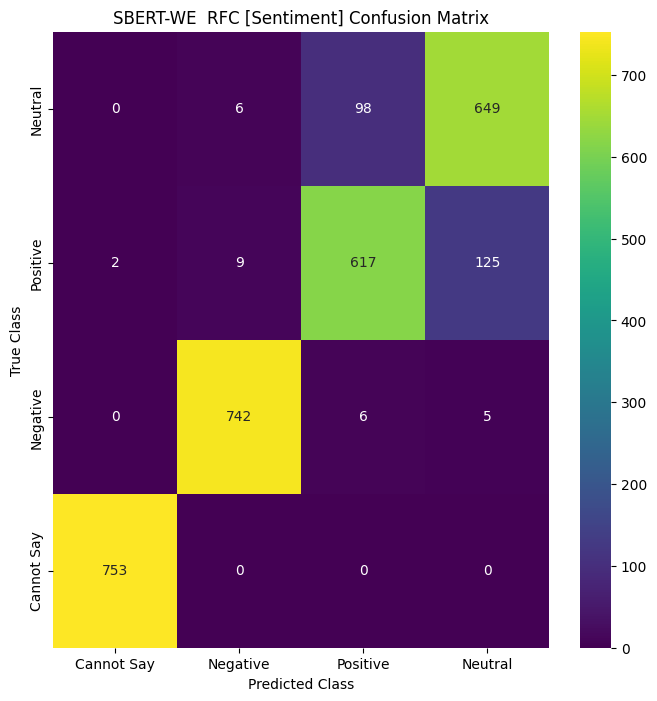

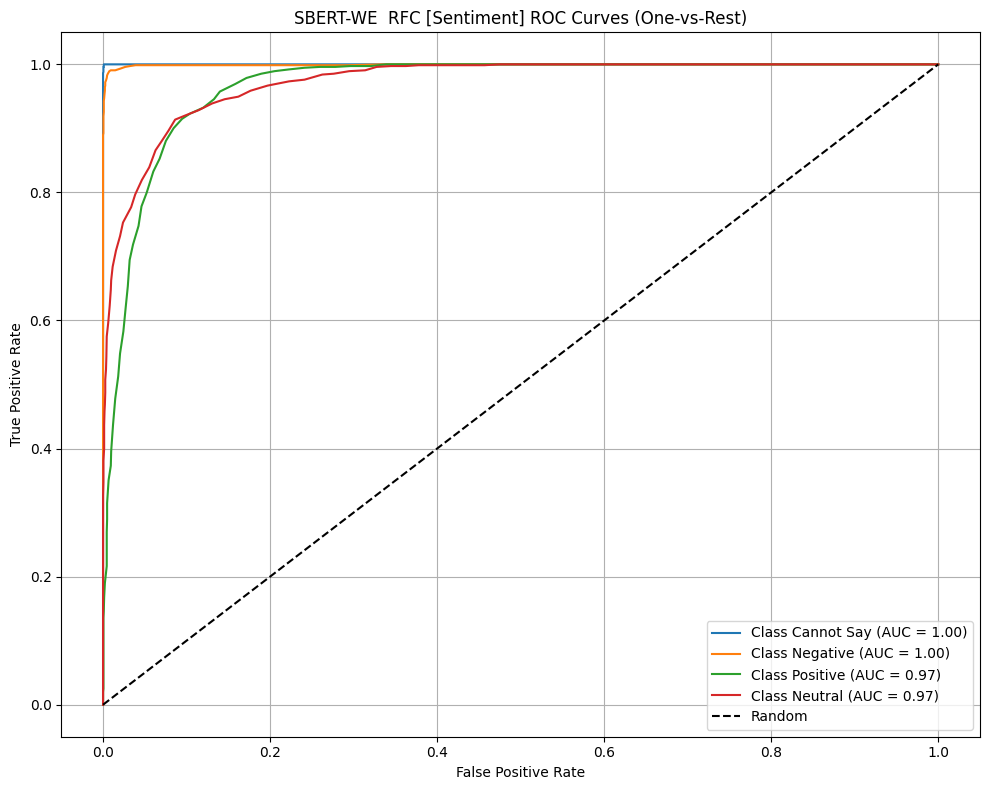

Loading existing LGBM model for Sentiment...
SBERT-WE  LGBM [Sentiment] Accuracy  : 93.26
SBERT-WE  LGBM [Sentiment] Precision : 93.25
SBERT-WE  LGBM [Sentiment] Recall    : 93.26
SBERT-WE  LGBM [Sentiment] FScore    : 93.25
SBERT-WE  LGBM [Sentiment] Classification Report
SBERT-WE  LGBM [Sentiment]
              precision    recall  f1-score   support

  Cannot Say       1.00      1.00      1.00       753
    Negative       0.97      0.97      0.97       753
    Positive       0.89      0.87      0.88       753
     Neutral       0.88      0.89      0.88       753

    accuracy                           0.93      3012
   macro avg       0.93      0.93      0.93      3012
weighted avg       0.93      0.93      0.93      3012




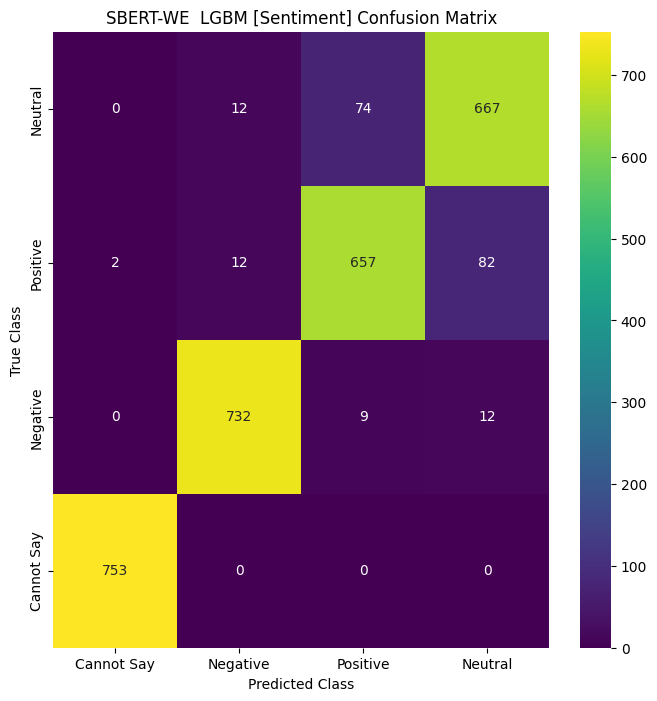

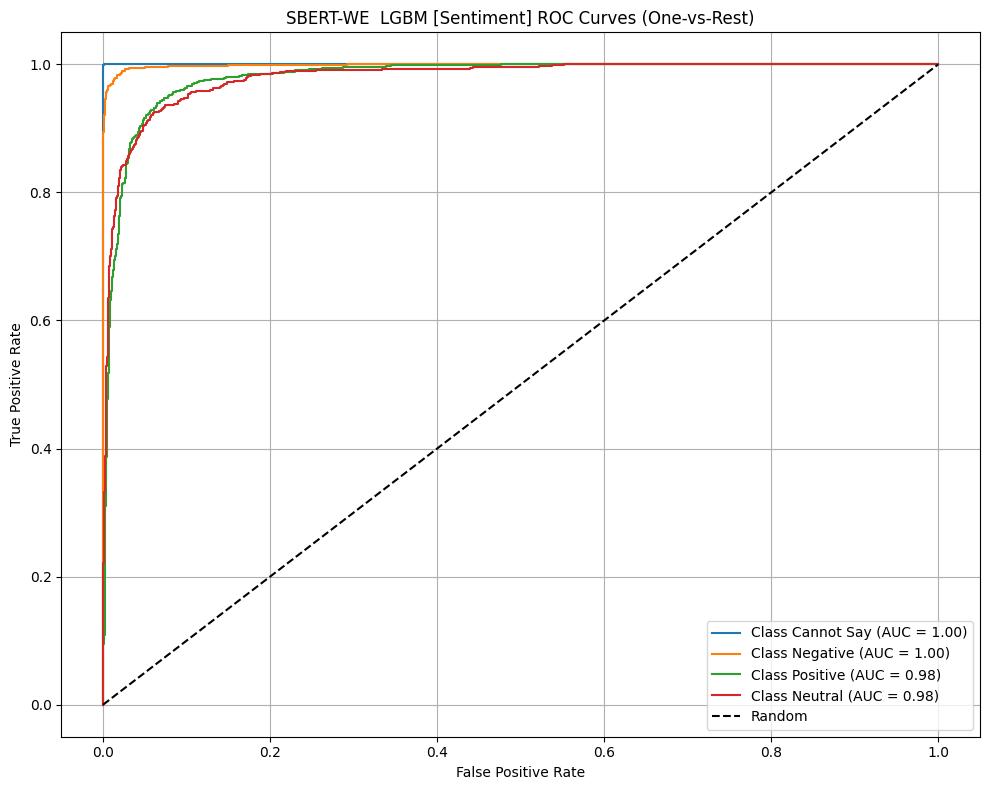

Loading existing XGB model for Sentiment...
SBERT-WE  XGB [Sentiment] Accuracy  : 93.53
SBERT-WE  XGB [Sentiment] Precision : 93.48
SBERT-WE  XGB [Sentiment] Recall    : 93.53
SBERT-WE  XGB [Sentiment] FScore    : 93.48
SBERT-WE  XGB [Sentiment] Classification Report
SBERT-WE  XGB [Sentiment]
              precision    recall  f1-score   support

  Cannot Say       0.99      1.00      0.99       753
    Negative       0.97      0.99      0.98       753
    Positive       0.90      0.85      0.88       753
     Neutral       0.88      0.90      0.89       753

    accuracy                           0.94      3012
   macro avg       0.93      0.94      0.93      3012
weighted avg       0.93      0.94      0.93      3012




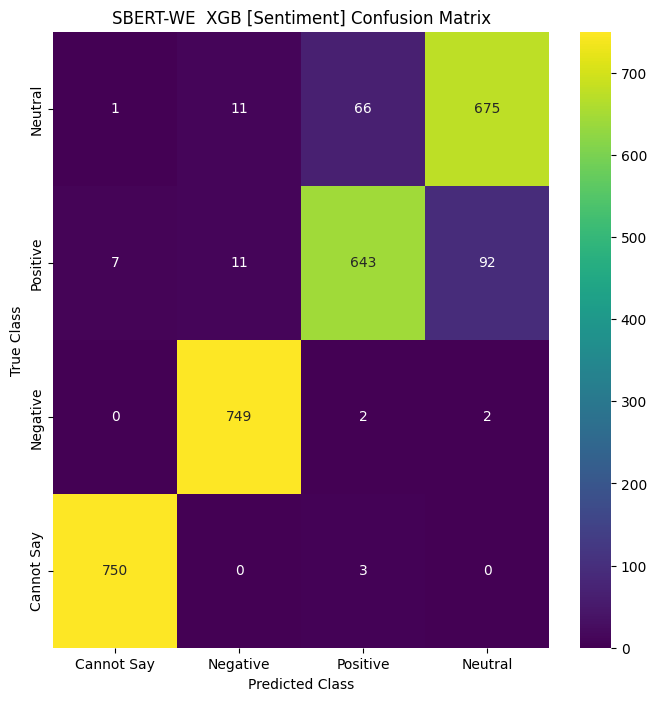

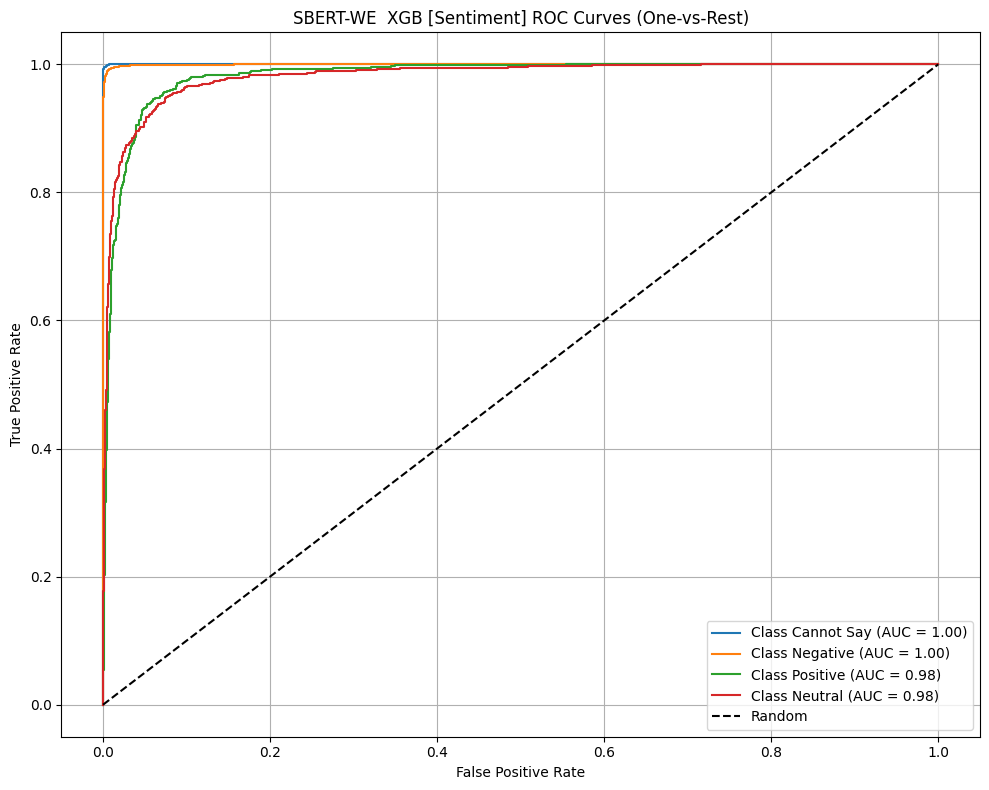

{'Sentiment_RFC': RandomForestClassifier(),
 'Sentiment_LGBM': LGBMClassifier(),
 'Sentiment_XGB': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...)}

In [47]:
import warnings

# Disable all warnings
warnings.filterwarnings("ignore")
train_multioutput_ml_ensemble("SBERT-WE ", features_dict, labels_dict)

In [48]:
def plot_training_history(history, title=None):
    """Plot training and validation accuracy/loss."""
    if history is None or not isinstance(history, dict):
        print("[ERROR] Invalid history format.")
        return

    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    if 'accuracy' in history:
        plt.subplot(1, 2, 1)
        plt.plot(history['accuracy'], label='Train Acc')
        if 'val_accuracy' in history:
            plt.plot(history['val_accuracy'], label='Val Acc')
        plt.title(f"{title} Accuracy" if title else "Accuracy")
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()

    # Loss Plot
    if 'loss' in history:
        plt.subplot(1, 2, 2)
        plt.plot(history['loss'], label='Train Loss')
        if 'val_loss' in history:
            plt.plot(history['val_loss'], label='Val Loss')
        plt.title(f"{title} Loss" if title else "Loss")
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

    plt.tight_layout()
    plt.show()
def plot_all_histories_from_folder(folder_path="model"):
    """Automatically read and plot all *_history.npy files in a folder."""
    history_files = [f for f in os.listdir(folder_path) if f.endswith("_history.npy")]

    if  history_files:
        print(history_files)

    for file in history_files:
        full_path = os.path.join(folder_path, file)
        try:
            history = np.load(full_path, allow_pickle=True).item()
            plot_training_history(history, title=file.replace("_history.npy", ""))
        except Exception as e:
            print(f"[ERROR] Could not load {file}: {e}")


In [49]:
def train_dense_sbert_classifier_extract_features(features_dict, labels_dict, model_prefix="SBERT"):
    extracted_features_dict = {}

    for target_name, y in labels_dict.items():
        X = features_dict[target_name]
        
        # File paths for each target
        model_path = f"model/{model_prefix}_{target_name}_dense_model.h5"
        feature_path = f"model/{model_prefix}_{target_name}_features.npy"
        history_path = f"model/{model_prefix}_{target_name}_history.npy"

        if all(os.path.exists(p) for p in [model_path, feature_path, history_path]):
            print(f"✅ [LOAD] {target_name}: Model and features found. Loading...")
            model = load_model(model_path)
            features = np.load(feature_path)
            extracted_features_dict[target_name] = features
            continue

        print(f"🚀 [TRAIN] {target_name}: No saved model found. Training new Dense model...")

        num_classes = len(np.unique(y))
        y_categorical = to_categorical(y, num_classes=num_classes)

        input_layer = Input(shape=(X.shape[1],))
        x = Dense(512, activation='relu')(input_layer)
        x = Dense(256, activation='relu')(x)
        x = Dense(128, activation='relu', name='feature_layer')(x)
        x = Dense(64, activation='relu')(x)
        output_layer = Dense(num_classes, activation='softmax')(x)

        model = Model(inputs=input_layer, outputs=output_layer)
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        history = model.fit(
            X, y_categorical,
            epochs=50,
            batch_size=32,
            validation_split=0.2,
            verbose=1
        )

        # Extract features from mid-layer
        feature_extractor = Model(inputs=model.input, outputs=model.get_layer('feature_layer').output)
        features = feature_extractor.predict(X)

        # Save results
        model.save(model_path)
        np.save(feature_path, features)
        np.save(history_path, history.history)

        print(f"💾 [SAVED] {target_name}: Model, features, and training history saved.")
        extracted_features_dict[target_name] = features

    return extracted_features_dict


In [50]:
extracted_features_dict = train_dense_sbert_classifier_extract_features(features_dict, labels_dict, model_prefix="SBERT-WE DNN")

✅ [LOAD] Sentiment: Model and features found. Loading...


['SBERT-WE DNN_Sentiment_history.npy']


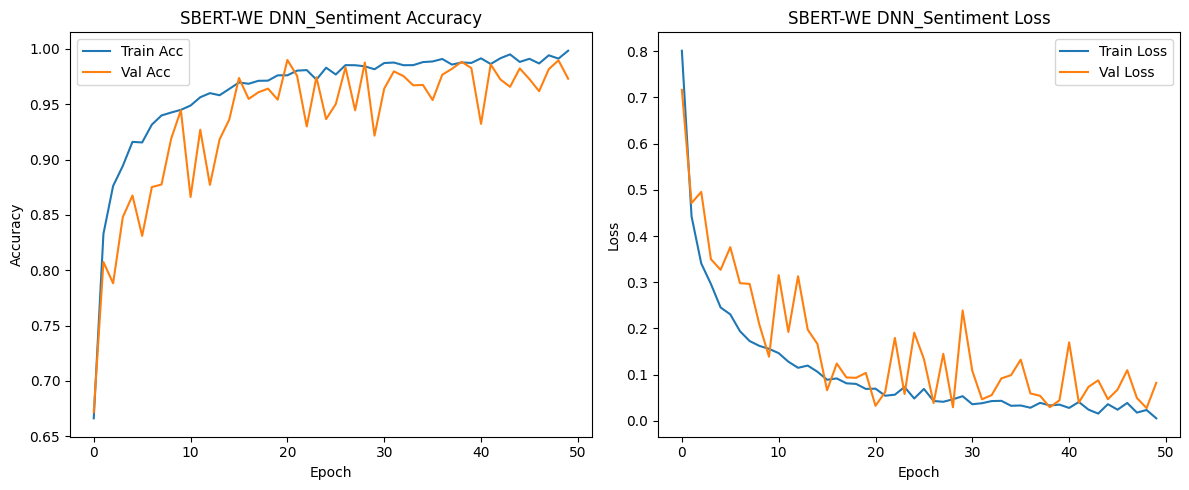

In [51]:
plot_all_histories_from_folder("model")

In [52]:
from imodels import BoostedRulesClassifier

def train_multioutput_boosted_rules(Algorithm_prefix, features_dict, labels_dict):
    """
    Train and evaluate BoostedRulesClassifier models for each target in a multi-output classification task.
    """
    model_results = {}

    for target_name, y_encoded in labels_dict.items():
        X = features_dict[target_name]
        model_path = f"model/{Algorithm_prefix}_{target_name}_BoostedRules_model.pkl"
        algo_name = f"{Algorithm_prefix} Boosted Rules [{target_name}]"

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
        )

        if os.path.exists(model_path):
            print(f"Loading existing BoostedRules model for {target_name}...")
            model = joblib.load(model_path)
        else:
            print(f"Training BoostedRulesClassifier for target: {target_name}...")
            model = BoostedRulesClassifier()
            model.fit(X_train, y_train)
            joblib.dump(model, model_path)

        y_pred = model.predict(X_test)

        try:
            y_score = model.predict_proba(X_test)
        except AttributeError:
            y_score = None

        # Metrics calculation
        if target_name == "Sentiment":
            metrics_calculator_lb.calculate_metrics(algo_name, y_pred, y_test, y_score)
        else:
            print(f"No metrics_calculator defined for: {target_name}")

        model_results[target_name] = model

    return model_results


Loading existing BoostedRules model for Sentiment...
SBERT-WE DNN Boosted Rules [Sentiment] Accuracy  : 98.47
SBERT-WE DNN Boosted Rules [Sentiment] Precision : 98.54
SBERT-WE DNN Boosted Rules [Sentiment] Recall    : 98.47
SBERT-WE DNN Boosted Rules [Sentiment] FScore    : 98.48
SBERT-WE DNN Boosted Rules [Sentiment] Classification Report
SBERT-WE DNN Boosted Rules [Sentiment]
              precision    recall  f1-score   support

  Cannot Say       1.00      0.99      0.99       753
    Negative       1.00      1.00      1.00       753
    Positive       1.00      0.96      0.98       753
     Neutral       0.95      1.00      0.97       753

    accuracy                           0.98      3012
   macro avg       0.99      0.98      0.98      3012
weighted avg       0.99      0.98      0.98      3012




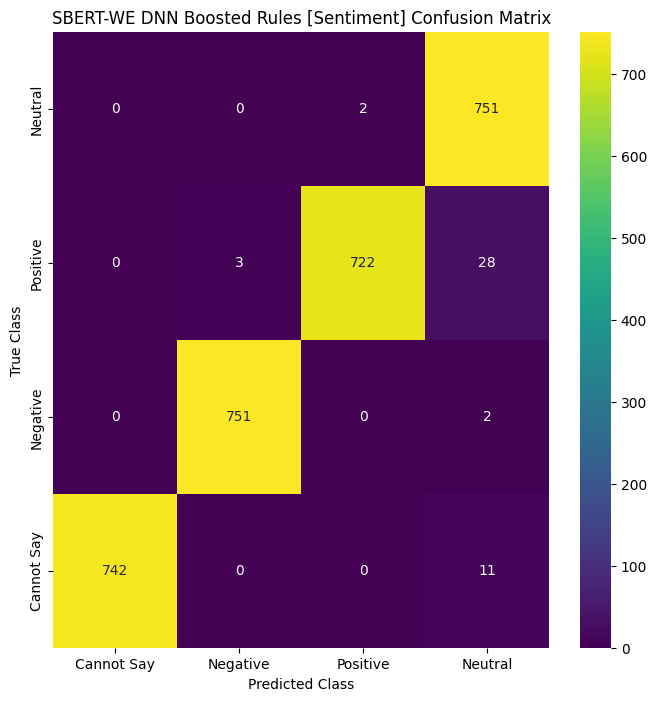

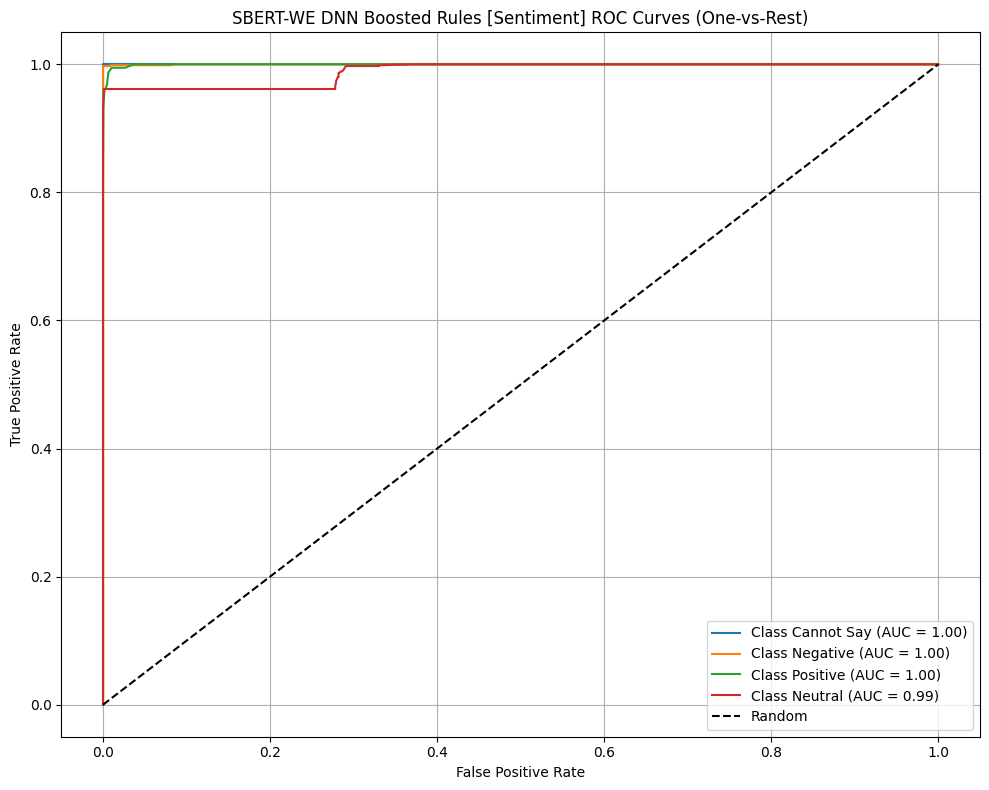

In [53]:
Final_models = train_multioutput_boosted_rules("SBERT-WE DNN", extracted_features_dict, labels_dict)

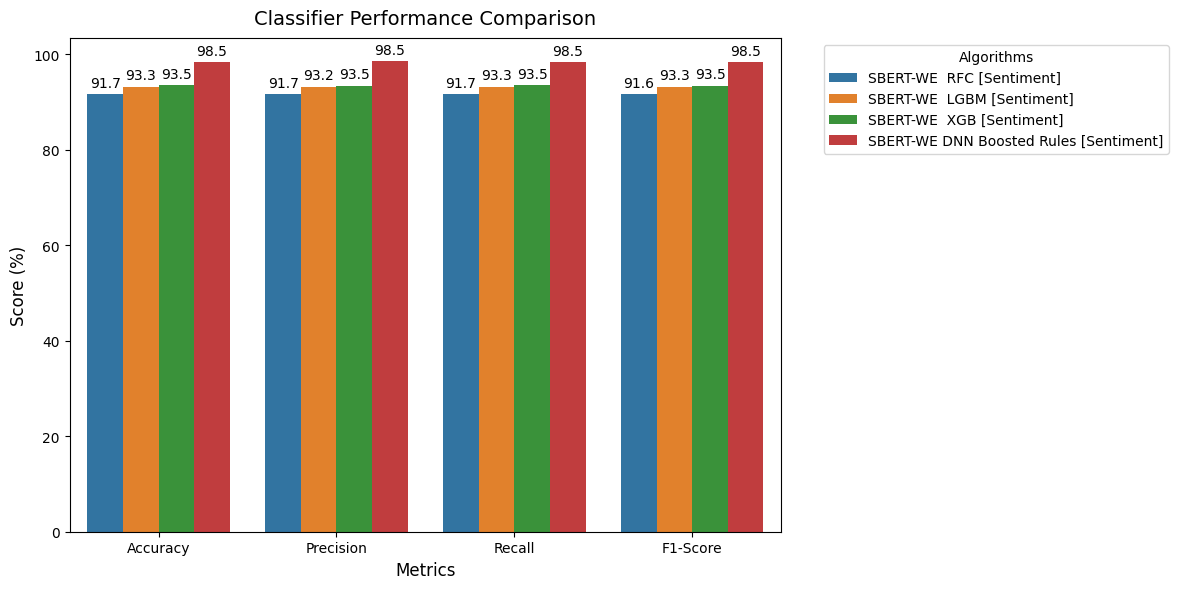

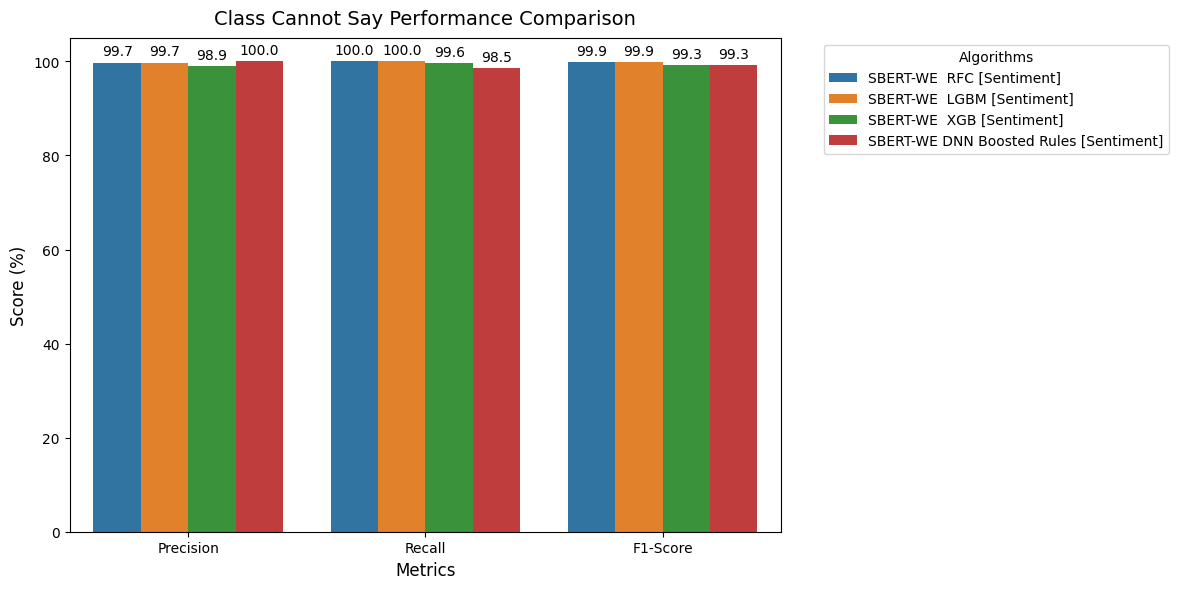

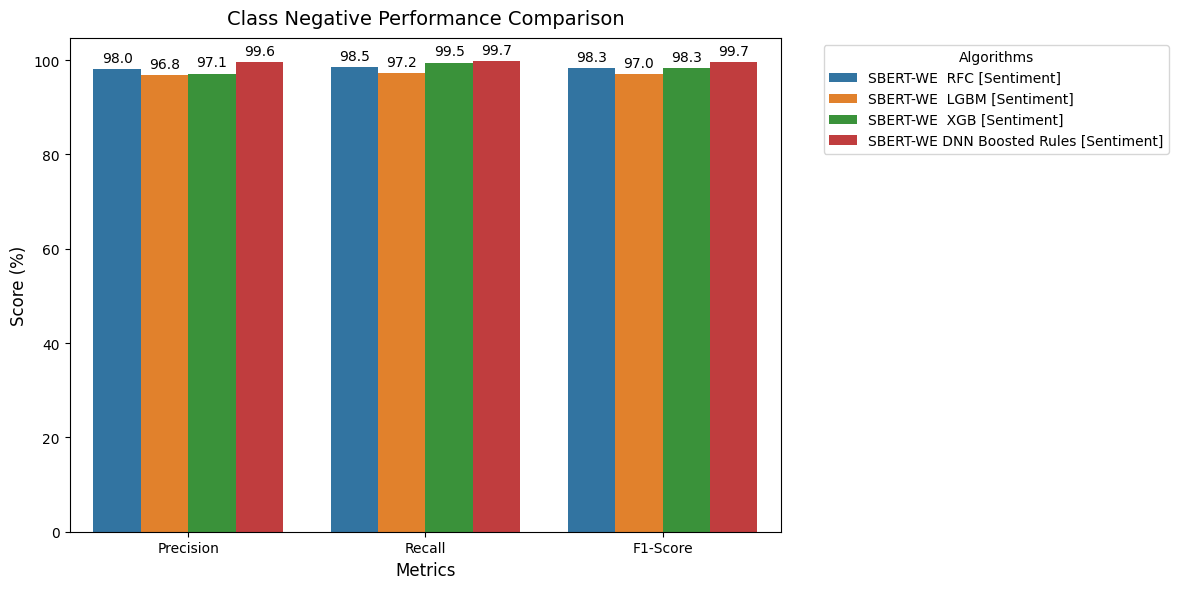

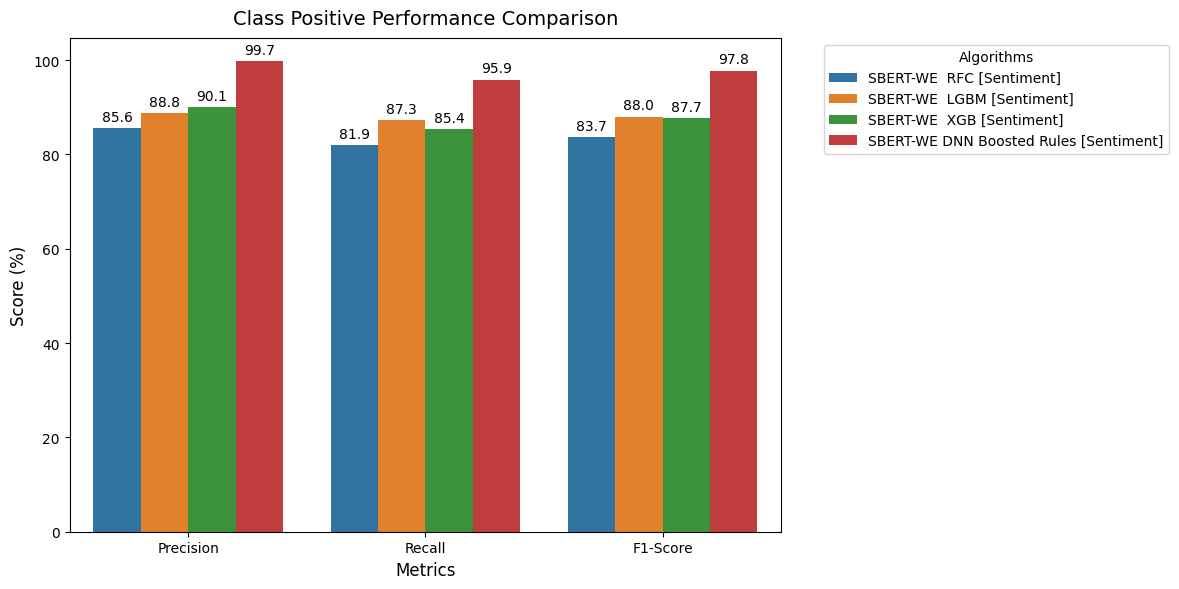

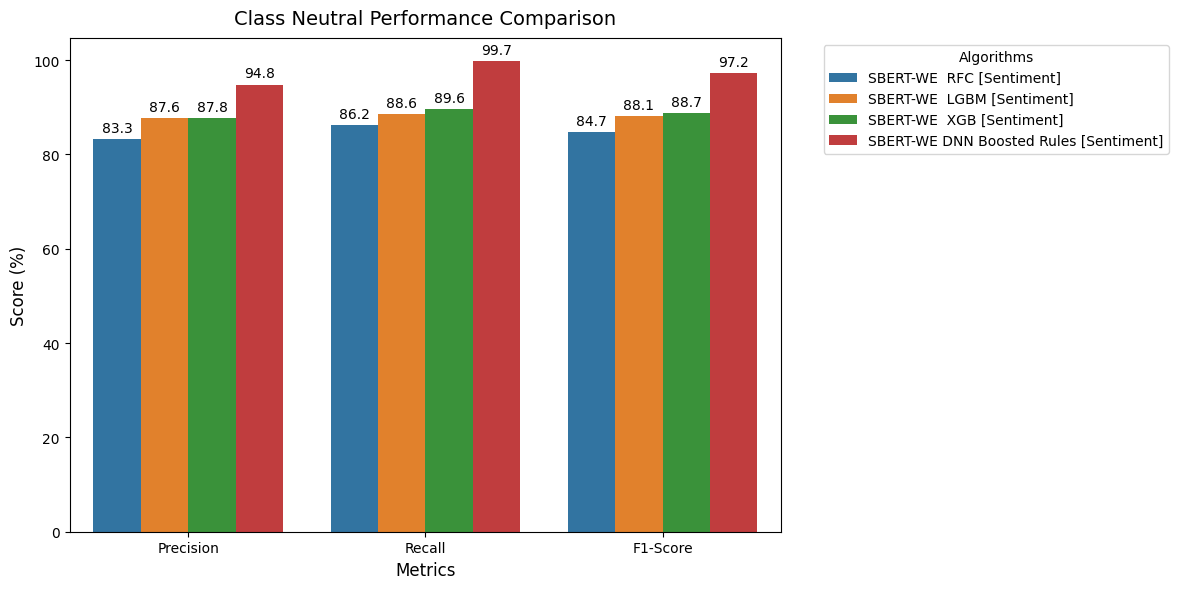

In [54]:
graph_plotter_lb = GraphPlotter(metrics_calculator_lb.metrics_df, metrics_calculator_lb.class_performance_dfs)
graph_plotter_lb.plot_all()

In [55]:
# Work-Life Balance
melted_df_lb = metrics_calculator_lb.metrics_df[['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].copy()
melted_df_lb = melted_df_lb.round(3)
melted_df_lb

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,SBERT-WE RFC [Sentiment],91.667,91.660,91.667,91.647
1,SBERT-WE LGBM [Sentiment],93.260,93.248,93.260,93.252
2,SBERT-WE XGB [Sentiment],93.526,93.481,93.526,93.482
3,SBERT-WE DNN Boosted Rules [Sentiment],98.473,98.537,98.473,98.479


In [56]:
def test_DNN_feature_extraction(features_test, model_base_name="SBERT-WE DNN", model_dir="model"):
    feature_outputs = {}
    targets = ["Sentiment"]

    for target in targets:
        model_filename = f"{model_base_name}_{target}_dense_model.h5"
        model_path = os.path.join(model_dir, model_filename)

        if not os.path.exists(model_path):
            print(f"❌ Model not found: {model_path}")
            continue

        print(f"✅ Loading model for {target}: {model_path}")
        model = load_model(model_path)

        try:
            feature_extractor = Model(inputs=model.input,
                                      outputs=model.get_layer("feature_layer").output)
        except:
            raise ValueError(f"Model does not contain a layer named 'feature_layer': {model_path}")

        print(f"🚀 Extracting features for {target}...")
        extracted_features = feature_extractor.predict(features_test)
        feature_outputs[target] = extracted_features

    return feature_outputs

In [57]:
test_path=r"Dataset/Test_Less.csv"

In [58]:
df_test1= upload_dataset(test_path)
df_test1
# Initialize result DataFrame
df_result = df_test1.copy()


In [59]:
df_test,_ = preprocess_data(df_test1)

Preprocessing data (no saving)


In [60]:
features_test = feature_extraction(df_test,method='SBERT with Word Embeddings',is_train=False)

[INFO] Feature extraction method: SBERT with Word Embeddings, Train mode: False
[INFO] Loading cached BERT features from model\X_SBERT with Word Embeddings.pkl


In [61]:
features_test = feature_extraction(df_test,method='SBERT-WE DNN',is_train=None)
feature_outputs_dict = test_DNN_feature_extraction(features_test)

[INFO] Feature extraction method: SBERT-WE DNN, Train mode: None
[INFO] Loading cached BERT features from model\X_SBERT-WE DNN.pkl
✅ Loading model for Sentiment: model\SBERT-WE DNN_Sentiment_dense_model.h5
🚀 Extracting features for Sentiment...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


In [62]:
classes = ["Cannot Say", "Negative", "Positive", "Neutral"]

# Loop over each target
for target in ['Sentiment']:
    # Get extracted features for current target
    target_features = feature_outputs_dict[target]

    # Predict using the model
    y_pred = Final_models[target].predict(target_features)

    # Map numeric predictions to label names
    mapped_labels = [classes[int(pred)] for pred in y_pred]

    # Add prediction column
    df_result[f'Predicted_{target}'] = mapped_labels

# Final output
df_result


,Text_ID,Product_Description,Product_Type,Predicted_Sentiment
0,3057,The Web DesignerÛªs Guide to iOS (and Android...,9,Positive
1,6254,RT @mention Line for iPad 2 is longer today th...,9,Positive
2,8212,Crazy that Apple is opening a temporary store ...,9,Positive
3,4422,The lesson from Google One Pass: In this digit...,9,Positive
4,5526,RT @mention At the panel: &quot;Your mom has a...,9,Positive
5,882,Comprando mi iPad 2 en el #SXSW (@mention Appl...,9,Cannot Say
6,4862,It is also limited in its abilities. Its a bal...,9,Cannot Say
7,7036,I think google circles was an effect of crop `...,9,Cannot Say
8,341,The queue at the Apple Store in Austin is FOUR...,9,Cannot Say
9,4618,Google/Bing search smackdown panel is in a gia...,9,Cannot Say
